In [1]:
import numpy as np
import torch
print(f"Numpy:  {np.__version__}")         # must show 1.26.4
print(f"Torch:  {torch.__version__}")      # must show 2.2.2+cu121
print(f"CUDA:   {torch.cuda.is_available()}")  # must show True

Numpy:  1.26.4
Torch:  2.2.2+cu121
CUDA:   True


In [1]:
# ============================================================
# Imports
# ============================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import timm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:

dataset_path = r"C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project\archive (3)\utkface_aligned_cropped\UTKFace"

CLASS_NAMES = ['Child (0-12)', 'Teenager (13-19)', 'Adult (20-50)', 'Elderly (51+)']

data = []
for filename in os.listdir(dataset_path):
    if not filename.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue
    parts = filename.split('_')
    try:
        age = int(parts[0])
    except (ValueError, IndexError):
        continue

    if age <= 12:
        group, label = 'Child (0-12)', 0
    elif age <= 19:
        group, label = 'Teenager (13-19)', 1
    elif age <= 50:
        group, label = 'Adult (20-50)', 2
    else:
        group, label = 'Elderly (51+)', 3

    data.append({
        'filename'   : filename,
        'actual_age' : age,
        'group'      : group,
        'label'      : label
    })

df = pd.DataFrame(data)

print("=== Full Dataset Distribution ===")
print(df['group'].value_counts())


# Stratified split: 70% train | 15% val | 15% test
train_df, temp_df = train_test_split(
    df, test_size=0.30,
    random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    random_state=42, stratify=temp_df['label']
)

print(f"\n=== Split Sizes (Full Dataset) ===")
print(f"Train : {len(train_df)} images")
print(f"Val   : {len(val_df)} images")
print(f"Test  : {len(test_df)} images")

print(f"\n=== Train Class Distribution ===")
print(train_df['group'].value_counts())

# ── Compute class weights for weighted loss ──────────────────
class_counts = train_df['label'].value_counts().sort_index().values
total        = len(train_df)
class_weights = torch.tensor(
    [total / (4 * c) for c in class_counts],
    dtype=torch.float32
).to(device)

print(f"\n=== Class Weights (for weighted loss) ===")
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f"  {name:20s} → weight: {w:.4f}")

=== Full Dataset Distribution ===
group
Adult (20-50)       14507
Elderly (51+)        4608
Child (0-12)         3413
Teenager (13-19)     1180
Name: count, dtype: int64

=== Split Sizes (Full Dataset) ===
Train : 16595 images
Val   : 3556 images
Test  : 3557 images

=== Train Class Distribution ===
group
Adult (20-50)       10155
Elderly (51+)        3225
Child (0-12)         2389
Teenager (13-19)      826
Name: count, dtype: int64

=== Class Weights (for weighted loss) ===
  Child (0-12)         → weight: 1.7366
  Teenager (13-19)     → weight: 5.0227
  Adult (20-50)        → weight: 0.4085
  Elderly (51+)        → weight: 1.2864


In [ ]:
# ============================================================
#  Dataset class + DataLoaders
# VGGFace2 normalization: mean=0.5, std=0.5 (NOT ImageNet values)
# ============================================================
class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(
                    os.path.join(self.img_dir, row['filename'])
                ).convert('RGB')
        label      = int(row['label'])
        actual_age = int(row['actual_age'])   # ← returned alongside label
        if self.transform:
            img = self.transform(img)
        return img, label, actual_age

# VGGFace2 normalization (face-specific, different from ImageNet)
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

def make_loaders(train_df, val_df, test_df, batch_size=32):
    train_ds = UTKFaceDataset(train_df, dataset_path, train_transform)
    val_ds   = UTKFaceDataset(val_df,   dataset_path, val_transform)
    test_ds  = UTKFaceDataset(test_df,  dataset_path, val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)
imgs, labels, ages = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}")
print(f"Labels      : {labels[:8].tolist()}")
print(f"Actual ages : {ages[:8].tolist()}")
print("Data pipeline OK!")

Batch shape : torch.Size([32, 3, 224, 224])
Labels      : [1, 2, 2, 3, 2, 3, 2, 2]
Actual ages : [18, 26, 40, 89, 45, 60, 26, 26]
Data pipeline OK!


In [3]:
# ============================================================
#  Load ResNet50 with VGGFace2 pretrained weights
# ============================================================
def build_model(freeze_strategy='classifier_only'):
    """
    freeze_strategy:
        'classifier_only' → freeze all conv layers, train only FC head
        'last_block'      → unfreeze layer4 + FC head
        'full'            → train all layers
    """
    model = timm.create_model(
        'resnet50',
        pretrained=True,
        num_classes=0    
    )

    # Custom classifier with Dropout for regularization
    in_features = model.num_features   # 2048 for ResNet50
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 4)
    )

    # Apply freeze strategy
    if freeze_strategy == 'classifier_only':
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    elif freeze_strategy == 'last_block':
        for name, param in model.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False

    elif freeze_strategy == 'full':
        pass

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable

    print(f"Freeze strategy : {freeze_strategy}")
    print(f"Total params    : {total:,}")
    print(f"Trainable       : {trainable:,}")
    print(f"Frozen          : {frozen:,}")

    return model.to(device)

# Test build
model = build_model('last_block')
print("\nModel loaded on:", next(model.parameters()).device)

Freeze strategy : last_block
Total params    : 23,516,228
Trainable       : 14,972,932
Frozen          : 8,543,296

Model loaded on: cuda:0


In [ ]:
# ============================================================
#  Training function with scheduler support
# ============================================================
def train_model(model, train_loader, val_loader,
                optimizer, num_epochs=10, scheduler=None):

    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0.0
    best_weights = None

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(num_epochs):
        start = time.time()

      
        model.train()
        running_loss = correct = total = 0

        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100 * correct / total

     
        model.eval()
        v_loss = correct = total = 0

        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
                v_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)

        val_loss = v_loss / len(val_loader)
        val_acc  = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

      
        if scheduler is not None:
            scheduler.step(val_acc)   # ReduceLROnPlateau uses val metric
            current_lr = optimizer.param_groups[0]['lr']
        else:
            current_lr = optimizer.param_groups[0]['lr']

        # Save best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            marker = ' ✓'
        else:
            marker = ''

        elapsed = time.time() - start
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}% | "
              f"LR: {current_lr:.6f} | {elapsed:.1f}s{marker}")

    print(f"\nBest Val Acc: {best_val_acc:.2f}%")
    return best_weights, best_val_acc, train_losses, val_losses, train_accs, val_accs

In [ ]:
# ============================================================
#  Structured hyperparameter search
# ============================================================

NUM_EPOCHS = 10


BASE_LR     = 0.0001
BASE_OPT    = 'Adam'
BASE_BATCH  = 32
BASE_FREEZE = 'classifier_only'

all_results = []

def run_experiment(exp_name, lr, opt_name, freeze_strat, batch_sz, round_name):
    print(f"\n{'─'*60}")
    print(f" {round_name} | {exp_name}")
    print(f" lr={lr} | opt={opt_name} | freeze={freeze_strat} | batch={batch_sz}")
    print(f"{'─'*60}")

    model = build_model(freeze_strat)
    t_loader, v_loader, _ = make_loaders(
        train_df, val_df, test_df, batch_size=batch_sz
    )

    trainable_params = list(filter(lambda p: p.requires_grad, model.parameters()))

    if opt_name == 'Adam':
        optimizer = optim.Adam(trainable_params, lr=lr)
    elif opt_name == 'AdamW':
        optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    elif opt_name == 'SGD':
        optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9)

    best_weights, best_val_acc, tr_losses, v_losses, tr_accs, v_accs = train_model(
        model, t_loader, v_loader, optimizer, NUM_EPOCHS
    )

    all_results.append({
        'Round'          : round_name,
        'Experiment'     : exp_name,
        'LR'             : lr,
        'Optimizer'      : opt_name,
        'Freeze'         : freeze_strat,
        'Batch Size'     : batch_sz,
        'Best Val Acc %' : round(best_val_acc, 2),
        'train_accs'     : tr_accs,
        'val_accs'       : v_accs,
    })

    return best_val_acc, best_weights


# ════════════════════════════════════════════════════════════
#  1: Find best Learning Rate
# Fixed: Adam, batch=32, freeze=classifier_only
# ════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print(" ROUND 1: Learning Rate Search")
print("█"*60)

lr_experiments = [
    ('LR=0.01',    0.01),
    ('LR=0.001',   0.001),
    ('LR=0.0001',  0.0001),
    ('LR=0.00001', 0.00001),
]

r1_results = {}
for name, lr in lr_experiments:
    acc, _ = run_experiment(name, lr, BASE_OPT, BASE_FREEZE, BASE_BATCH, 'Round1_LR')
    r1_results[name] = acc

best_lr_name = max(r1_results, key=r1_results.get)
BEST_LR = float(best_lr_name.split('=')[1])

print(f"\n{'═'*60}")
print(f" Round 1 Results:")
for name, acc in sorted(r1_results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ← BEST' if name == best_lr_name else ''
    print(f"   {name:20s} → Val Acc: {acc:.2f}%{marker}")
print(f"\n✅ Best LR: {BEST_LR}")
print(f"{'═'*60}")


# ════════════════════════════════════════════════════════════
#  2: Find best Optimizer
# Fixed: BEST_LR, batch=32, freeze=classifier_only
# ════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print(" ROUND 2: Optimizer Search")
print(f" (using BEST_LR={BEST_LR} from Round 1)")
print("█"*60)

opt_experiments = [
    ('Adam',  'Adam'),
    ('AdamW', 'AdamW'),
    ('SGD',   'SGD'),
]

r2_results = {}
for name, opt in opt_experiments:
    acc, _ = run_experiment(name, BEST_LR, opt, BASE_FREEZE, BASE_BATCH, 'Round2_Optimizer')
    r2_results[name] = acc

BEST_OPT = max(r2_results, key=r2_results.get)

print(f"\n{'═'*60}")
print(f" Round 2 Results:")
for name, acc in sorted(r2_results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ← BEST' if name == BEST_OPT else ''
    print(f"   {name:20s} → Val Acc: {acc:.2f}%{marker}")
print(f"\n✅ Best Optimizer: {BEST_OPT}")
print(f"{'═'*60}")


# ════════════════════════════════════════════════════════════
#  3: Find best Batch Size
# Fixed: BEST_LR, BEST_OPT, freeze=classifier_only
# ════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print(" ROUND 3: Batch Size Search")
print(f" (using BEST_LR={BEST_LR}, BEST_OPT={BEST_OPT} from previous rounds)")
print("█"*60)

batch_experiments = [
    ('Batch=16', 16),
    ('Batch=32', 32),
    ('Batch=64', 64),
]

r3_results = {}
for name, batch in batch_experiments:
    acc, _ = run_experiment(name, BEST_LR, BEST_OPT, BASE_FREEZE, batch, 'Round3_Batch')
    r3_results[name] = acc

best_batch_name = max(r3_results, key=r3_results.get)
BEST_BATCH = int(best_batch_name.split('=')[1])

print(f"\n{'═'*60}")
print(f" Round 3 Results:")
for name, acc in sorted(r3_results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ← BEST' if name == best_batch_name else ''
    print(f"   {name:20s} → Val Acc: {acc:.2f}%{marker}")
print(f"\n✅ Best Batch Size: {BEST_BATCH}")
print(f"{'═'*60}")


# ════════════════════════════════════════════════════════════
#  4: Find best Freeze Strategy
# Fixed: BEST_LR, BEST_OPT, BEST_BATCH
# ════════════════════════════════════════════════════════════
print("\n" + "█"*60)
print(" ROUND 4: Freeze Strategy Search")
print(f" (using BEST_LR={BEST_LR}, BEST_OPT={BEST_OPT}, BEST_BATCH={BEST_BATCH})")
print("█"*60)

freeze_experiments = [
    ('classifier_only', 'classifier_only'),
    ('last_block',      'last_block'),
    ('full_finetune',   'full'),
]

r4_results = {}
for name, freeze in freeze_experiments:
    acc, _ = run_experiment(name, BEST_LR, BEST_OPT, freeze, BEST_BATCH, 'Round4_Freeze')
    r4_results[name] = acc

best_freeze_name = max(r4_results, key=r4_results.get)
BEST_FREEZE = freeze_experiments[[f[0] for f in freeze_experiments].index(best_freeze_name)][1]

print(f"\n{'═'*60}")
print(f" Round 4 Results:")
for name, acc in sorted(r4_results.items(), key=lambda x: x[1], reverse=True):
    marker = ' ← BEST' if name == best_freeze_name else ''
    print(f"   {name:20s} → Val Acc: {acc:.2f}%{marker}")
print(f"\n✅ Best Freeze Strategy: {BEST_FREEZE}")
print(f"{'═'*60}")



print("\n\n" + "█"*60)
print(" FINAL BEST CONFIGURATION")
print("█"*60)
print(f"  Learning Rate    : {BEST_LR}")
print(f"  Optimizer        : {BEST_OPT}")
print(f"  Batch Size       : {BEST_BATCH}")
print(f"  Freeze Strategy  : {BEST_FREEZE}")
print("█"*60)

# ── Save results to CSV ──────────────────────────────────────
save_dir   = r"C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project"
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('train_accs', 'val_accs')}
    for r in all_results
])
summary_df.to_csv(os.path.join(save_dir, 'hyperparameter_results.csv'), index=False)
print(f"\nFull results saved to hyperparameter_results.csv")


████████████████████████████████████████████████████████████
 ROUND 1: Learning Rate Search
████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────
 Round1_LR | LR=0.01
 lr=0.01 | opt=Adam | freeze=classifier_only | batch=32
────────────────────────────────────────────────────────────
Freeze strategy : classifier_only
Total params    : 23,516,228
Trainable       : 8,196
Frozen          : 23,508,032
Epoch [01/10] Train Loss: 1.0954 | Train Acc: 52.8% | Val Loss: 0.9785 | Val Acc: 58.8% | 19.3s ✓
Epoch [02/10] Train Loss: 0.9488 | Train Acc: 59.0% | Val Loss: 0.9183 | Val Acc: 60.6% | 20.1s ✓
Epoch [03/10] Train Loss: 0.9162 | Train Acc: 61.4% | Val Loss: 0.8899 | Val Acc: 61.0% | 22.7s ✓
Epoch [04/10] Train Loss: 0.8732 | Train Acc: 63.9% | Val Loss: 0.8997 | Val Acc: 61.7% | 33.1s ✓
Epoch [05/10] Train Loss: 0.8516 | Train Acc: 64.7% | Val Loss: 0.8514 | Val Acc: 63.3% | 30.7s ✓
Epoch [06/10] Train Loss: 0.8384 | Train

In [13]:
print(BEST_LR, BEST_OPT, BEST_BATCH, BEST_FREEZE)

0.01 Adam 32 last_block


In [ ]:
# ============================================================
# Final training with all data + weighted loss
# ============================================================

SAVE_DIR = r"C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project"

print("█"*60)
print(" FINAL TRAINING V3 — Full Data + Weighted Loss + Scheduler")
print(f" LR={BEST_LR} | Opt={BEST_OPT} | Batch={BEST_BATCH} | Freeze={BEST_FREEZE}")
print(f" Training samples: {len(train_df)}")
print("█"*60)

# Fresh model
final_model = build_model(BEST_FREEZE)

# Loaders
train_loader, val_loader, test_loader = make_loaders(
    train_df, val_df, test_df, batch_size=BEST_BATCH
)

# Optimizer
trainable_params = list(filter(
    lambda p: p.requires_grad, final_model.parameters()
))
final_optimizer = optim.Adam(trainable_params, lr=BEST_LR)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer, mode='max', factor=0.5,
    patience=3, verbose=False
)



def train_model_weighted(model, train_loader, val_loader,
                         optimizer, num_epochs=20,
                         scheduler=None, class_weights=None):

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    best_val_acc = 0.0
    best_weights = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(num_epochs):
        start = time.time()

        # Training
        model.train()
        running_loss = correct = total = 0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100 * correct / total

        # Validation
        model.eval()
        v_loss = correct = total = 0
        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
                v_loss += loss.item()
                _, pred = torch.max(outputs, 1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)

        val_loss = v_loss / len(val_loader)
        val_acc  = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if scheduler is not None:
            scheduler.step(val_acc)
        current_lr = optimizer.param_groups[0]['lr']

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            marker = ' ✓'
        else:
            marker = ''

        elapsed = time.time() - start
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}% | "
              f"LR: {current_lr:.6f} | {elapsed:.1f}s{marker}")

    print(f"\nBest Val Acc: {best_val_acc:.2f}%")
    return best_weights, best_val_acc, train_losses, val_losses, train_accs, val_accs

# Train
best_weights, best_val_acc, train_losses, val_losses, train_accs, val_accs = \
    train_model_weighted(
        final_model, train_loader, val_loader,
        final_optimizer, num_epochs=20,
        scheduler=scheduler,
        class_weights=class_weights
    )

# Save
final_model.load_state_dict(best_weights)
model_path = os.path.join(SAVE_DIR, 'best_vggface2_resnet50_age_v3.pth')
torch.save(best_weights, model_path)
print(f"\nModel saved: {model_path}")

████████████████████████████████████████████████████████████
 FINAL TRAINING V3 — Full Data + Weighted Loss + Scheduler
 LR=0.01 | Opt=Adam | Batch=32 | Freeze=last_block
 Training samples: 16595
████████████████████████████████████████████████████████████
Freeze strategy : last_block
Total params    : 23,516,228
Trainable       : 14,972,932
Frozen          : 8,543,296


c:\Users\salma\.conda\envs\gpu_env\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch [01/20] Train Loss: 0.8501 | Train Acc: 64.6% | Val Loss: 0.7733 | Val Acc: 72.5% | LR: 0.010000 | 180.2s ✓
Epoch [02/20] Train Loss: 0.6849 | Train Acc: 70.8% | Val Loss: 0.6763 | Val Acc: 60.1% | LR: 0.010000 | 141.2s
Epoch [03/20] Train Loss: 0.6366 | Train Acc: 72.7% | Val Loss: 0.6568 | Val Acc: 77.0% | LR: 0.010000 | 106.2s ✓
Epoch [04/20] Train Loss: 0.5778 | Train Acc: 75.3% | Val Loss: 0.5960 | Val Acc: 79.0% | LR: 0.010000 | 84.0s ✓
Epoch [05/20] Train Loss: 0.5277 | Train Acc: 76.1% | Val Loss: 0.5507 | Val Acc: 74.4% | LR: 0.010000 | 84.4s
Epoch [06/20] Train Loss: 0.5095 | Train Acc: 76.9% | Val Loss: 0.5752 | Val Acc: 74.7% | LR: 0.010000 | 85.6s
Epoch [07/20] Train Loss: 0.4829 | Train Acc: 78.3% | Val Loss: 0.5738 | Val Acc: 79.1% | LR: 0.010000 | 83.9s ✓
Epoch [08/20] Train Loss: 0.4701 | Train Acc: 78.7% | Val Loss: 0.5565 | Val Acc: 69.9% | LR: 0.010000 | 85.2s
Epoch [09/20] Train Loss: 0.4304 | Train Acc: 80.0% | Val Loss: 0.6159 | Val Acc: 81.4% | LR: 0.01000

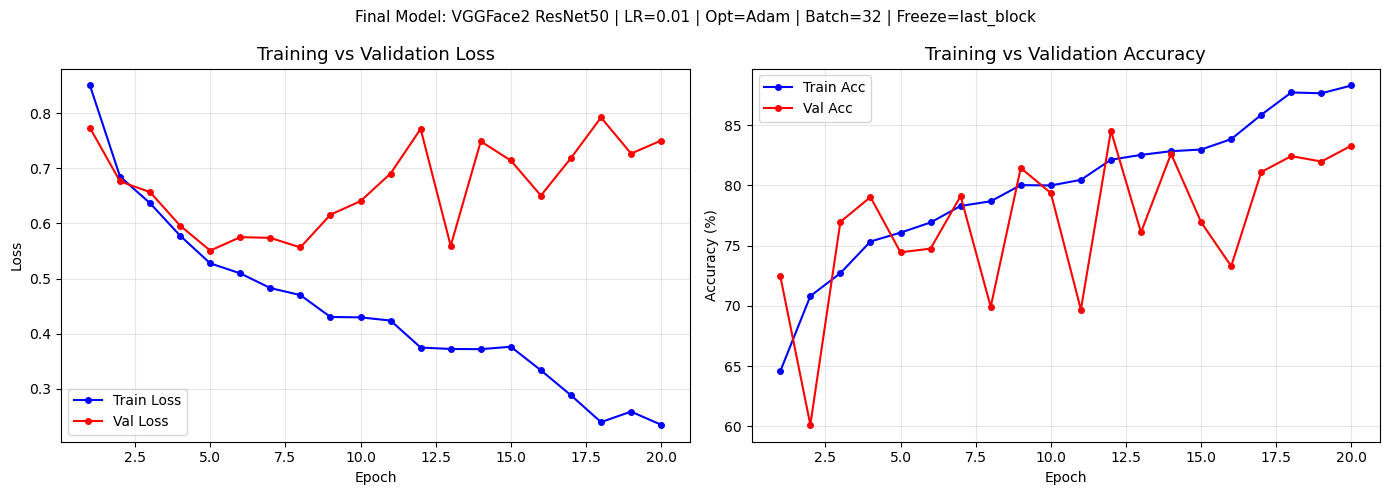

Training curves saved.


In [ ]:
# ============================================================
#  training curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 21)

# Loss
axes[0].plot(epochs, train_losses, 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs, val_losses,   'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, train_accs, 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs, val_accs,   'r-o', markersize=4, label='Val Acc')
axes[1].set_title('Training vs Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Final Model: VGGFace2 ResNet50 | LR={BEST_LR} | '
    f'Opt={BEST_OPT} | Batch={BEST_BATCH} | Freeze={BEST_FREEZE}',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    Child (0-12)       0.94      0.88      0.91       512
Teenager (13-19)       0.51      0.44      0.47       177
   Adult (20-50)       0.90      0.89      0.89      2176
   Elderly (51+)       0.75      0.82      0.78       692

        accuracy                           0.85      3557
       macro avg       0.77      0.76      0.76      3557
    weighted avg       0.85      0.85      0.85      3557

Overall Test Accuracy: 85.32%


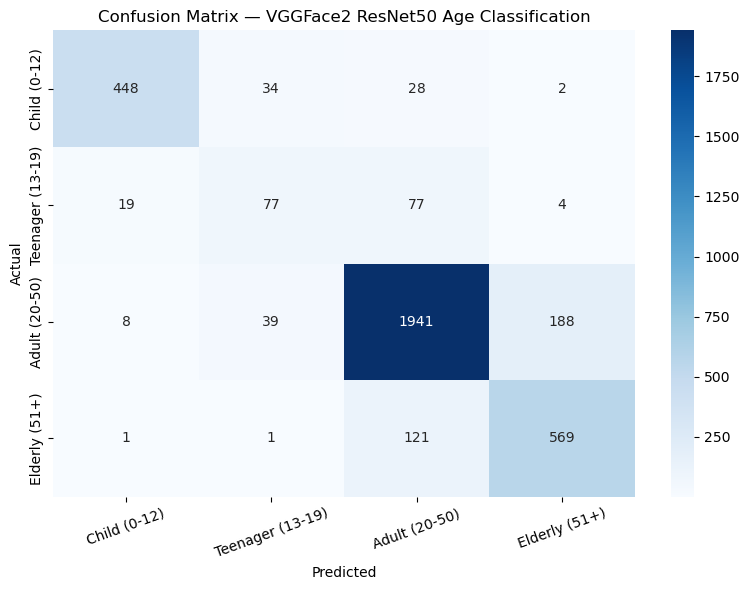

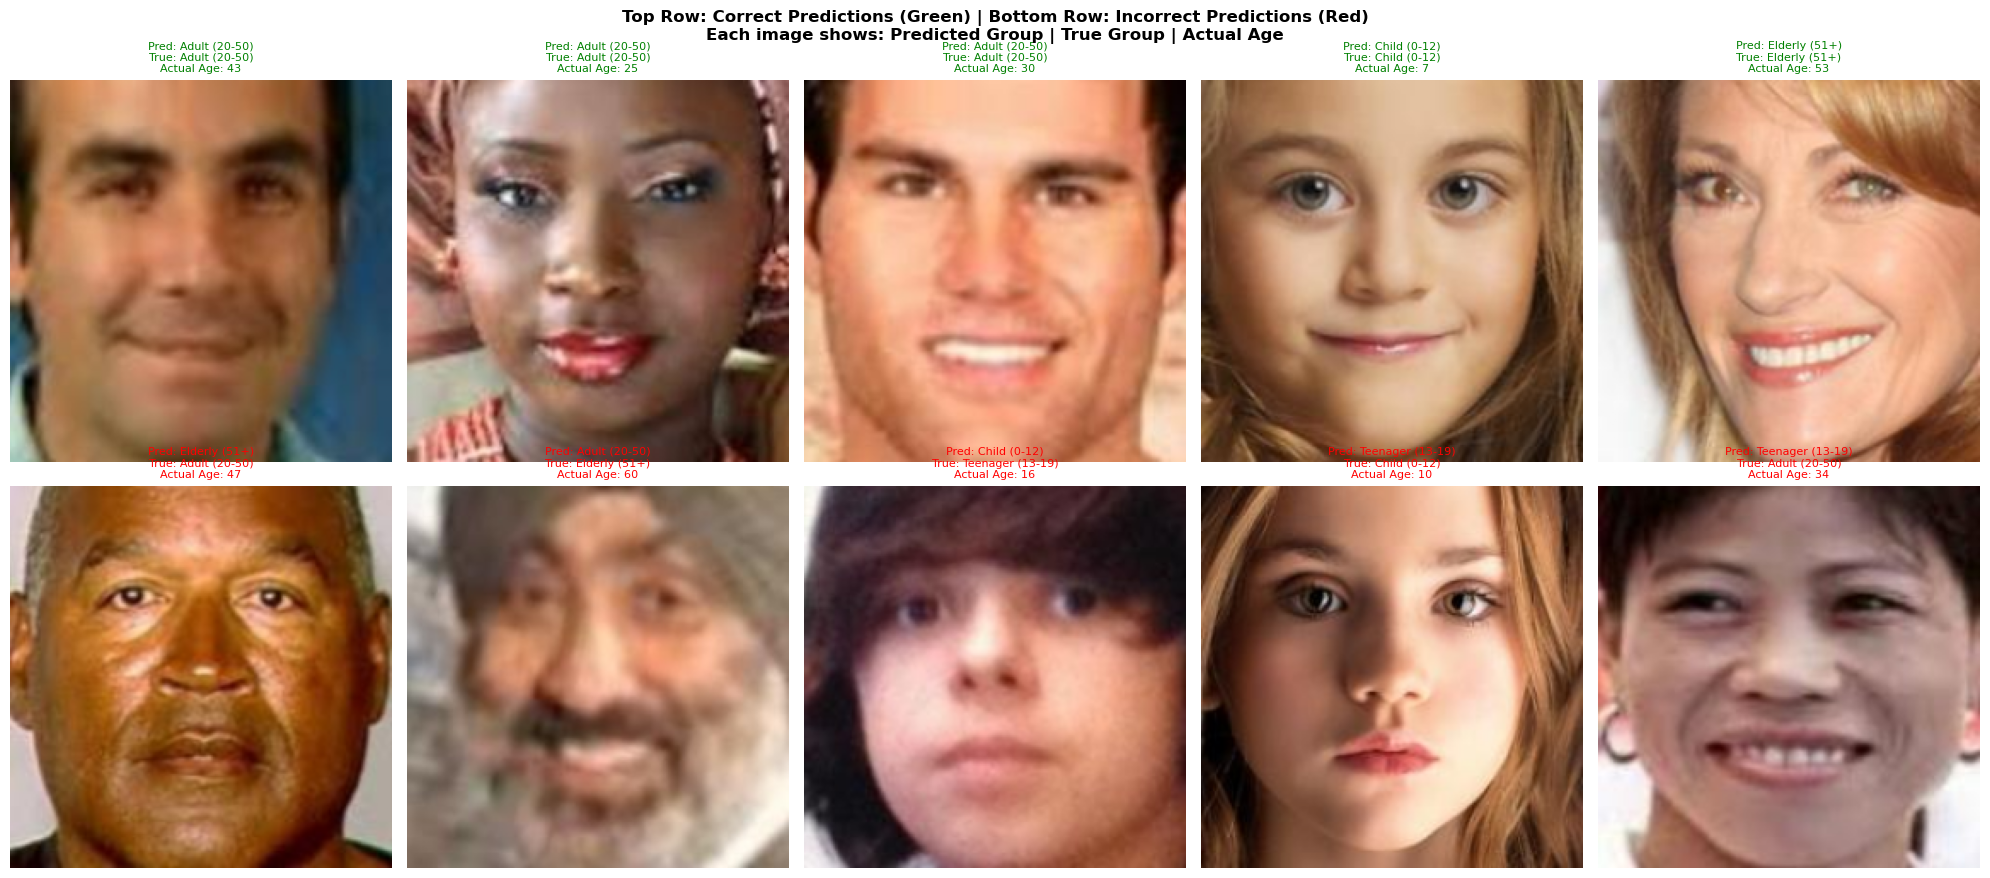

Prediction samples saved.


In [ ]:
# ============================================================
#  Final evaluation on test set
#  predicted group, true group, actual age
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix

final_model.eval()

all_preds  = []
all_labels = []
all_ages   = []

with torch.no_grad():
    for imgs, labels, actual_ages in test_loader:
        imgs = imgs.to(device)
        outputs = final_model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_ages.extend(actual_ages.numpy())

# ── Classification Report ────────────────────────────────────
print("="*60)
print(" CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

test_acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Overall Test Accuracy: {test_acc:.2f}%")

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — VGGFace2 ResNet50 Age Classification', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Visual Predictions with Actual Age ───────────────────────
def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

sample_imgs, sample_labels, sample_preds, sample_ages = [], [], [], []

final_model.eval()
with torch.no_grad():
    for imgs, labels, ages in test_loader:
        out = final_model(imgs.to(device))
        _, pred = torch.max(out, 1)
        for i in range(len(labels)):
            sample_imgs.append(imgs[i])
            sample_labels.append(labels[i].item())
            sample_preds.append(pred[i].item())
            sample_ages.append(ages[i].item())
        if len(sample_imgs) >= 100:
            break

correct_idx = [i for i in range(len(sample_labels)) if sample_labels[i] == sample_preds[i]]
wrong_idx   = [i for i in range(len(sample_labels)) if sample_labels[i] != sample_preds[i]]

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle(
    'Top Row: Correct Predictions (Green) | Bottom Row: Incorrect Predictions (Red)\n'
    'Each image shows: Predicted Group | True Group | Actual Age',
    fontsize=12, fontweight='bold'
)

for col in range(5):
    # Correct
    idx = correct_idx[col]
    img = denormalize(sample_imgs[idx]).permute(1, 2, 0).numpy()
    axes[0][col].imshow(img)
    axes[0][col].set_title(
        f"Pred: {CLASS_NAMES[sample_preds[idx]]}\n"
        f"True: {CLASS_NAMES[sample_labels[idx]]}\n"
        f"Actual Age: {sample_ages[idx]}",
        color='green', fontsize=8
    )
    axes[0][col].axis('off')

    # Incorrect
    idx = wrong_idx[col]
    img = denormalize(sample_imgs[idx]).permute(1, 2, 0).numpy()
    axes[1][col].imshow(img)
    axes[1][col].set_title(
        f"Pred: {CLASS_NAMES[sample_preds[idx]]}\n"
        f"True: {CLASS_NAMES[sample_labels[idx]]}\n"
        f"Actual Age: {sample_ages[idx]}",
        color='red', fontsize=8
    )
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'prediction_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Prediction samples saved.")

In [ ]:
# ============================================================
#  Save all results and model states
# ============================================================
import pickle

SAVE_DIR = r"C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project"

# ── 1. Save best hyperparameters ────────────────────────────
best_config = {
    'BEST_LR'     : BEST_LR,
    'BEST_OPT'    : BEST_OPT,
    'BEST_BATCH'  : BEST_BATCH,
    'BEST_FREEZE' : BEST_FREEZE,
}
with open(os.path.join(SAVE_DIR, 'best_config.pkl'), 'wb') as f:
    pickle.dump(best_config, f)
print("✅ Best config saved")

# ── 2. Save all hyperparameter experiment results ────────────
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('train_accs', 'val_accs')}
    for r in all_results
])
summary_df.to_csv(os.path.join(SAVE_DIR, 'all_hyperparameter_results.csv'), index=False)
print("✅ Hyperparameter results saved")

# ── 3. Save training curves data ────────────────────────────
curves = {
    'train_losses' : train_losses,
    'val_losses'   : val_losses,
    'train_accs'   : train_accs,
    'val_accs'     : val_accs,
    'best_val_acc' : best_val_acc,
}
with open(os.path.join(SAVE_DIR, 'training_curves_data.pkl'), 'wb') as f:
    pickle.dump(curves, f)
print("✅ Training curves data saved")

# ── 4. Save dataset splits ───────────────────────────────────
train_df.to_csv(os.path.join(SAVE_DIR, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(SAVE_DIR,   'val_split.csv'),   index=False)
test_df.to_csv(os.path.join(SAVE_DIR,  'test_split.csv'),  index=False)
print("✅ Dataset splits saved")

# ── 5. Save predictions ──────────────────────────────────────
predictions_df = pd.DataFrame({
    'true_label'  : all_labels,
    'pred_label'  : all_preds,
    'actual_age'  : all_ages,
    'true_group'  : [CLASS_NAMES[l] for l in all_labels],
    'pred_group'  : [CLASS_NAMES[p] for p in all_preds],
    'correct'     : [p == l for p, l in zip(all_preds, all_labels)]
})
predictions_df.to_csv(os.path.join(SAVE_DIR, 'test_predictions.csv'), index=False)
print("✅ Test predictions saved")

print(f"\n{'='*50}")
print(f" All files saved to:")
print(f" {SAVE_DIR}")
print(f"{'='*50}")
print(f"\n Files saved:")
print(f"  best_config.pkl")
print(f"  all_hyperparameter_results.csv")
print(f"  training_curves_data.pkl")
print(f"  train/val/test_split.csv")
print(f"  test_predictions.csv")
print(f"  best_vggface2_resnet50_age.pth  (already saved)")

✅ Best config saved
✅ Hyperparameter results saved
✅ Training curves data saved
✅ Dataset splits saved
✅ Test predictions saved

 All files saved to:
 C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project

 Files saved:
  best_config.pkl
  all_hyperparameter_results.csv
  training_curves_data.pkl
  train/val/test_split.csv
  test_predictions.csv
  best_vggface2_resnet50_age.pth  (already saved)


In [26]:
# Save V3 results
import pickle

curves_v3 = {
    'train_losses' : train_losses,
    'val_losses'   : val_losses,
    'train_accs'   : train_accs,
    'val_accs'     : val_accs,
    'best_val_acc' : best_val_acc,
}
with open(os.path.join(SAVE_DIR, 'training_curves_v3.pkl'), 'wb') as f:
    pickle.dump(curves_v3, f)

predictions_df = pd.DataFrame({
    'true_label' : all_labels,
    'pred_label' : all_preds,
    'actual_age' : all_ages,
    'true_group' : [CLASS_NAMES[l] for l in all_labels],
    'pred_group' : [CLASS_NAMES[p] for p in all_preds],
    'correct'    : [p == l for p, l in zip(all_preds, all_labels)]
})
predictions_df.to_csv(os.path.join(SAVE_DIR, 'test_predictions_v3.csv'), index=False)

train_df.to_csv(os.path.join(SAVE_DIR, 'train_split_v3.csv'), index=False)
val_df.to_csv(os.path.join(SAVE_DIR,   'val_split_v3.csv'),   index=False)
test_df.to_csv(os.path.join(SAVE_DIR,  'test_split_v3.csv'),  index=False)

print("✅ All V3 results saved")

✅ All V3 results saved


In [ ]:
# ============================================================
#  Live camera age group prediction
#  V3 model (85.32% accuracy)
# ============================================================
import cv2
from PIL import Image
import torch.nn.functional as F

# Load best V3 model
final_model = build_model(BEST_FREEZE)
final_model.load_state_dict(torch.load(
    os.path.join(SAVE_DIR, 'best_vggface2_resnet50_age_v3.pth')
))
final_model.eval()
print("✅ Model loaded")

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Colors per class (BGR)
COLORS = {
    'Child (0-12)'    : (0,   255, 0),
    'Teenager (13-19)': (255, 255, 0),
    'Adult (20-50)'   : (0,   165, 255),
    'Elderly (51+)'   : (0,   0,   255),
}

AGE_RANGES = {
    'Child (0-12)'    : '0-12',
    'Teenager (13-19)': '13-19',
    'Adult (20-50)'   : '20-50',
    'Elderly (51+)'   : '51+',
}

print("Camera starting... Press Q to quit.")

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Could not open camera.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.3,
            minNeighbors=5, minSize=(60, 60)
        )

        for (x, y, w, h) in faces:
            # Preprocess
            face_bgr = frame[y:y+h, x:x+w]
            face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
            face_pil = Image.fromarray(face_rgb)
            face_tensor = val_transform(face_pil).unsqueeze(0).to(device)

            # Predict + get all class probabilities
            with torch.no_grad():
                output = final_model(face_tensor)
                probs  = F.softmax(output, dim=1)[0]
                confidence, predicted = torch.max(probs, 0)
                label = CLASS_NAMES[predicted.item()]
                conf  = confidence.item() * 100

            color = COLORS[label]

            # Bounding box
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

            # Main label above box
            main_text = f"{label}  ({conf:.0f}%)"
            cv2.putText(frame, main_text,
                        (x, y - 12),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.65, color, 2)

            # Age range below box
            cv2.putText(frame, f"Age: {AGE_RANGES[label]}",
                        (x, y + h + 22),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.55, color, 2)

            # Confidence bar below age range
            bar_w = int(w * confidence.item())
            cv2.rectangle(frame,
                          (x, y + h + 30),
                          (x + w, y + h + 42),
                          (80, 80, 80), -1)
            cv2.rectangle(frame,
                          (x, y + h + 30),
                          (x + bar_w, y + h + 42),
                          color, -1)

            # All 4 class probabilities on the side
            for i, (cname, prob) in enumerate(zip(CLASS_NAMES, probs)):
                prob_text = f"{cname[:5]}: {prob.item()*100:.0f}%"
                txt_color = COLORS[cname]
                cv2.putText(frame, prob_text,
                            (x + w + 8, y + 20 + i * 22),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5, txt_color, 1)

        # Instructions
        cv2.putText(frame, "VGGFace2 ResNet50 | Age Group Detection",
                    (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (255, 255, 255), 2)
        cv2.putText(frame, "Press Q to quit",
                    (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (200, 200, 200), 1)

        cv2.imshow('VGGFace2 Age Group Detection', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Camera closed.")

Freeze strategy : last_block
Total params    : 23,516,228
Trainable       : 14,972,932
Frozen          : 8,543,296
✅ Model loaded
Camera starting... Press Q to quit.
Camera closed.


In [6]:
BEST_LR     = 0.01
BEST_OPT    = 'Adam'
BEST_BATCH  = 32
BEST_FREEZE = 'last_block'
SAVE_DIR    = r"C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project"
print(f"✅ Config restored")

✅ Config restored


In [7]:
from deepface import DeepFace
print("DeepFace ready ✅")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"BEST_FREEZE: {BEST_FREEZE}")
print(f"SAVE_DIR exists: {os.path.exists(SAVE_DIR)}")


26-05-15 05:01:11 - Directory C:\Users\salma\.deepface has been created
26-05-15 05:01:11 - Directory C:\Users\salma\.deepface\weights has been created
DeepFace ready ✅
CUDA: True
BEST_FREEZE: last_block
SAVE_DIR exists: True


In [7]:
import torch
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

CLASS_NAMES = ['Adult (20-50)', 'Child (0-12)', 'Elderly (51+)', 'Teenager (13-19)']

print(f"device: {device}")
print(f"val_transform: ✅")
print(f"CLASS_NAMES: {CLASS_NAMES}")

device: cuda
val_transform: ✅
CLASS_NAMES: ['Adult (20-50)', 'Child (0-12)', 'Elderly (51+)', 'Teenager (13-19)']


In [9]:
import cv2
from PIL import Image
import torch.nn.functional as F

# ── Colors per class (BGR) ───────────────────────────────────
COLORS = {
    'Child (0-12)'    : (0,   255, 0),
    'Teenager (13-19)': (255, 255, 0),
    'Adult (20-50)'   : (0,   165, 255),
    'Elderly (51+)'   : (0,   0,   255),
}

AGE_RANGES = {
    'Child (0-12)'    : '0-12',
    'Teenager (13-19)': '13-19',
    'Adult (20-50)'   : '20-50',
    'Elderly (51+)'   : '51+',
}

print("Camera starting... Press Q to quit.")

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Could not open camera.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.3,
            minNeighbors=5, minSize=(60, 60)
        )

        for face_idx, (x, y, w, h) in enumerate(faces):

            face_bgr = frame[y:y+h, x:x+w]
            face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

            face_pil    = Image.fromarray(face_rgb)
            face_tensor = val_transform(face_pil).unsqueeze(0).to(device)

            with torch.no_grad():
                output     = final_model(face_tensor)
                probs      = F.softmax(output, dim=1)[0]
                conf, pred = torch.max(probs, 0)
                label      = CLASS_NAMES[pred.item()]
                confidence = conf.item() * 100

            color = COLORS[label]

            # ── Bounding box ─────────────────────────────────
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

            # ── Label + confidence above box ─────────────────
            cv2.putText(frame,
                        f"{label}  ({confidence:.0f}%)",
                        (x, y - 15),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.60, color, 2)

            # ── Age range below box ───────────────────────────
            cv2.putText(frame,
                        f"Range: {AGE_RANGES[label]}",
                        (x, y + h + 22),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.55, color, 2)

            # ── Confidence bar ────────────────────────────────
            bar_w = int(w * conf.item())
            cv2.rectangle(frame,
                          (x,         y + h + 30),
                          (x + w,     y + h + 42),
                          (80, 80, 80), -1)
            cv2.rectangle(frame,
                          (x,         y + h + 30),
                          (x + bar_w, y + h + 42),
                          color, -1)

            # ── All 4 class probabilities on right side ───────
            for i, (cname, prob) in enumerate(zip(CLASS_NAMES, probs)):
                bar_len = int(80 * prob.item())
                txt_col = COLORS[cname]
                cv2.putText(frame,
                            f"{cname[:5]}: {prob.item()*100:.0f}%",
                            (x + w + 10, y + 20 + i * 22),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.48, txt_col, 1)
                cv2.rectangle(frame,
                              (x + w + 10,            y + 25 + i * 22),
                              (x + w + 10 + bar_len,  y + 30 + i * 22),
                              txt_col, -1)

        # ── Header bar ───────────────────────────────────────
        cv2.rectangle(frame, (0, 0), (frame.shape[1], 40), (0, 0, 0), -1)
        cv2.putText(frame,
                    "VGGFace2 ResNet50 | Age Group: 85.32% Acc  |  Q to quit",
                    (10, 26),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.60, (255, 255, 255), 2)

        cv2.imshow('Age Detection — VGGFace2', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Camera closed.")

Camera starting... Press Q to quit.
Camera closed.


In [10]:
# ── Final save before closing ────────────────────────────────
import pickle

# Save best config
with open(os.path.join(SAVE_DIR, 'best_config.pkl'), 'wb') as f:
    pickle.dump({
        'BEST_LR'    : BEST_LR,
        'BEST_OPT'   : BEST_OPT,
        'BEST_BATCH' : BEST_BATCH,
        'BEST_FREEZE': BEST_FREEZE,
    }, f)
print("✅ Config saved")

# Confirm all important files exist on disk
import os
files_to_check = [
    'best_vggface2_resnet50_age_v3.pth',
    'best_config.pkl',
    'all_hyperparameter_results.csv',
    'train_split_v3.csv',
    'val_split_v3.csv',
    'test_split_v3.csv',
    'training_curves.png',
    'confusion_matrix.png',
]

print("\n=== Files on disk ===")
for f in files_to_check:
    full_path = os.path.join(SAVE_DIR, f)
    status = "✅" if os.path.exists(full_path) else "❌ MISSING"
    print(f"  {status}  {f}")

✅ Config saved

=== Files on disk ===
  ✅  best_vggface2_resnet50_age_v3.pth
  ✅  best_config.pkl
  ✅  all_hyperparameter_results.csv
  ✅  train_split_v3.csv
  ✅  val_split_v3.csv
  ✅  test_split_v3.csv
  ✅  training_curves.png
  ✅  confusion_matrix.png


In [5]:
import pickle, os

SAVE_DIR = r"C:\Users\salma\Desktop\Term 8\Image Processing & Pattern Recognition\project"

with open(os.path.join(SAVE_DIR, 'best_config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

BEST_LR     = cfg['BEST_LR']
BEST_OPT    = cfg['BEST_OPT']
BEST_BATCH  = cfg['BEST_BATCH']
BEST_FREEZE = cfg['BEST_FREEZE']

print(f"✅ Loaded: LR={BEST_LR}, OPT={BEST_OPT}, BATCH={BEST_BATCH}, FREEZE={BEST_FREEZE}")

✅ Loaded: LR=0.01, OPT=Adam, BATCH=32, FREEZE=last_block
